# Ensembl VEP Annotations









In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.proteingym as pg 
import src.onekg as og

import matplotlib.pyplot as plt
import seaborn as sns
import pooch
from tqdm import tqdm
import polars as pl

pd.set_option('display.max_columns', None)

/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [ ]:
vep_files = va.list_vep_files(as_df=True)
vep_files.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 681512 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 7
scoring_strategy: 3
variant_set: 1
haplotype: 85106
protein: 2142


,file,protein,haplotype,variant_set,model_location,scoring_strategy
0,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
1,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,masked-marginals
2,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
3,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,masked-marginals
4,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:914L>V,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals


In [ ]:
vep_df = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[vep_files['model_location']=="esm2_t33_650M_UR50D"]
    )

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 57984 masked-marginals parquet files


Reading files:   0%|          | 0/57984 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 7.31GB/s]


VEP dataframe shape: (2028077, 72)


In [12]:
# Calculate mean and std for each protein/mutant combination (excluding REF)
non_ref_stats = vep_df[~vep_df['is_ref']].groupby(['protein', 'mutant'])['VEP'].agg(['mean', 'std']).reset_index()

# # Merge stats back with original dataframe
# Drop mean and std columns if they exist before merging
cols_to_drop = ['mean', 'std']
existing_cols = [col for col in cols_to_drop if col in vep_df.columns]
if existing_cols:
    vep_df = vep_df.drop(columns=existing_cols)
vep_df = vep_df.merge(non_ref_stats, on=['protein', 'mutant'], how='left')

# Calculate z-score for REF haplotypes to determine how many standard deviations each is from its distribution's mean
vep_df.loc[vep_df['is_ref'], 'z_score'] = (vep_df.loc[vep_df['is_ref'], 'VEP'] - vep_df.loc[vep_df['is_ref'], 'mean']) / vep_df.loc[vep_df['is_ref'], 'std']
vep_df.loc[:,"z_score_abs"] = vep_df["z_score"].abs()

Distribution of z-scores for REF haplotypes:
                VEP          mean           std       z_score   z_score_abs
count  36074.000000  35609.000000  35249.000000  3.524900e+04  3.524900e+04
mean      -4.524708     -4.493326      0.112819          -inf           inf
std        4.396153      4.379593      0.339107           NaN           NaN
min      -17.160425    -17.176952      0.000000          -inf  8.363814e-06
25%       -8.235437     -8.173360      0.020897 -3.350728e-01  1.209073e-01
50%       -3.597906     -3.556052      0.041434 -1.565511e-01  2.297417e-01
75%       -0.713956     -0.703462      0.083877  6.436638e-02  3.902483e-01
max        8.752159      8.624454      5.954381  6.488263e+01           inf


/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/schilder/.conda/envs/esm2/lib/python3.13/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


99.55034858297925
97.65273709830453


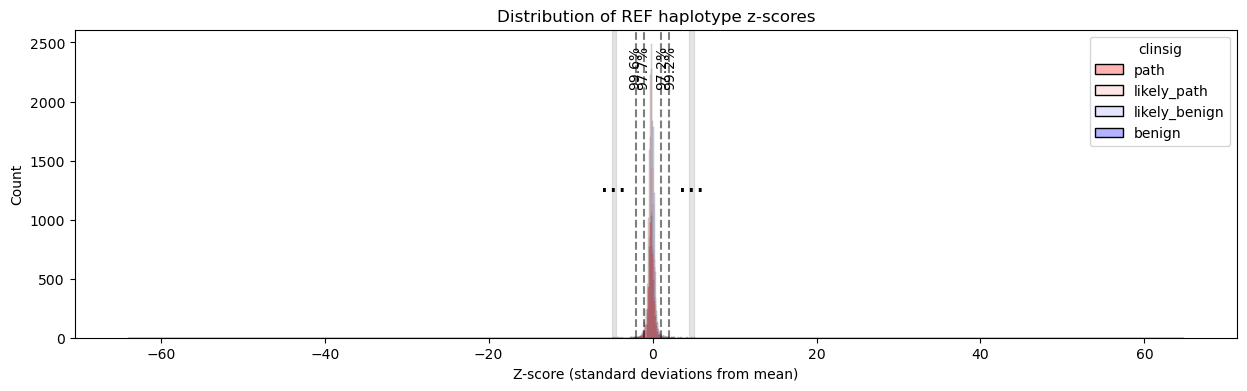

In [ ]:
va.plot_vep_variance_zscore(vep_df)

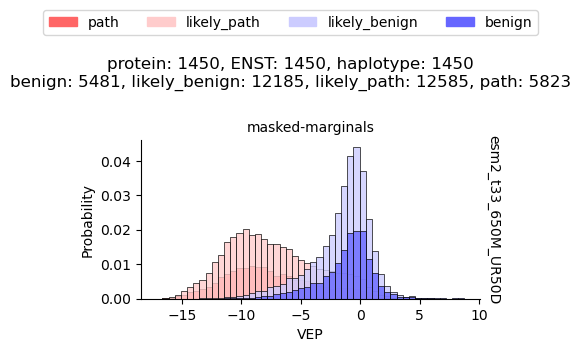

In [94]:
# Reference only
va.plot_vep_density(vep_df.loc[vep_df["is_ref"]==True], 
                    bins=50,
                    stat="probability",
                     plot_func = sns.histplot)

Filtered 0.5% of rows with NAs in col 'VEP'


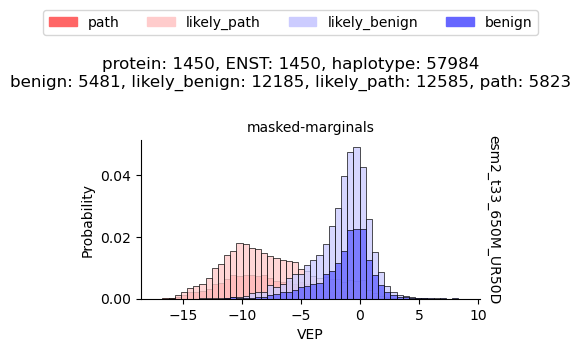

In [95]:
# All data
va.plot_vep_density(vep_df, 
                    bins=50,
                    stat="probability",
                     plot_func = sns.histplot)

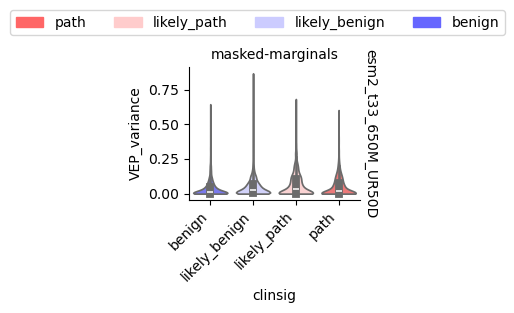

In [ ]:
va.plot_vep_variance(vep_df, func=sns.violinplot, cut=0,
                                           groupby_cols = ['model_location','protein','clinsig','mutant','scoring_strategy'],
)

## Merge annotation files

In [532]:
cached_file = os.path.join(pooch.os_cache("pooch"), "cv_annot_ProteinGym_missense.csv.gz")

if os.path.exists(cached_file):
    cv_annot = pd.read_csv(cached_file)
else:
    import glob
    cv_vep_files = glob.glob(os.path.join(pooch.os_cache("pooch"), "clinvar_by_chrom", "clinvarVEP*"))

    cv_annot = []
    for f in tqdm(cv_vep_files):
        cv_tmp = pd.read_csv(f, sep="\t", low_memory=False, na_values=['-'])

        cv_tmp = cv_tmp.loc[cv_tmp["Consequence"].str.contains("missense_variant")] 

        # Add mutant col
        cv_tmp.loc[:, "mutant"] = cv_tmp["Amino_acids"].str.split("/").str[0] + cv_tmp["Protein_position"] + cv_tmp["Amino_acids"].str.split("/").str[1]

        # Filter ENST according to vep_df
        cv_tmp.loc[:, "ENST"] = cv_tmp["Feature"].str.split(".").str[0]
        cv_tmp = cv_tmp.loc[cv_tmp["ENST"].isin(vep_df["ENST"].unique().tolist())]
        
        # Filter mutants according to vep_df
        cv_tmp = cv_tmp.loc[cv_tmp["mutant"].isin(vep_df["mutant"].unique().tolist())]
        
        cv_annot.append(cv_tmp)
    cv_annot = pd.concat(cv_annot)
    print(f"Caching merged and filtered annotations --> {cached_file}")
    cv_annot.to_csv(cached_file, index=False)


import numpy as np

# Extract numeric values from PolyPhen column using regex
cv_annot['SIFT_score'] = cv_annot['SIFT'].str.extract(r'\(([\d.]+)\)').astype(float)
cv_annot['PolyPhen_score'] = cv_annot['PolyPhen'].str.extract(r'\(([\d.]+)\)').astype(float)


cv_annot['MaveDB_score_mean'] = cv_annot['MaveDB_score'].str.split(',').apply(lambda x: np.mean([float(i) for i in x]) if isinstance(x, list) else np.nan)
cv_annot['MaveDB_score_abs_mean'] = cv_annot['MaveDB_score'].str.split(',').apply(lambda x: np.mean([abs(float(i)) for i in x]) if isinstance(x, list) else np.nan)
cv_annot['MaveDB_score_min'] = cv_annot['MaveDB_score'].str.split(',').apply(lambda x: np.min([float(i) for i in x]) if isinstance(x, list) else np.nan)
cv_annot['MaveDB_score_max'] = cv_annot['MaveDB_score'].str.split(',').apply(lambda x: np.max([float(i) for i in x]) if isinstance(x, list) else np.nan)

print(cv_annot.shape)
cv_annot.head()

/tmp/ipykernel_1586596/2786123952.py:4: DtypeWarning: Columns (29,66,67,84,86) have mixed types. Specify dtype option on import or set low_memory=False.
  cv_annot = pd.read_csv(cached_file)


(109275, 116)


,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,SOURCE,SIFT,PolyPhen,AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,OpenTargets_geneId,OpenTargets_l2g,CADD_PHRED,CADD_RAW,am_class,am_pathogenicity,LOEUF,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,REVEL,BLOSUM62,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,EVE_CLASS,EVE_SCORE,pHaplo,pTriplo,ada_score,rf_score,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,ClinPred,AllOfUs,AllOfUs_gvs_all_af,AllOfUs_gvs_max_af,AllOfUs_gvs_afr_af,AllOfUs_gvs_amr_af,AllOfUs_gvs_eas_af,AllOfUs_gvs_eur_af,AllOfUs_gvs_mid_af,AllOfUs_gvs_oth_af,AllOfUs_gvs_sas_af,mutant,ENST,SIFT_score,PolyPhen_score,MaveDB_score_mean,MaveDB_score_abs_mean,MaveDB_score_min,MaveDB_score_max
0,161196,1:1535370-1535370,A,missense_variant,MODERATE,TMEM240,ENSG00000205090,Transcript,ENST00000378733.9,protein_coding,4/4,NaN,NaN,NaN,789,511,171,R/W,Cgg/Tgg,"rs606231455,CM148749,COSV59235425",G,G/A,NaN,-1.0,NaN,HGNC,HGNC:25186,MANE_Select,NM_001114748.2,NaN,2.0,P1,NaN,deleterious(0),possibly_damaging(0.833),NaN,7.872000e-06,0.000000,0.000000,0.00004,0.0,0.0,0.0,7.419000e-06,0.000017,0.000013,0.000020,0.000000,0.0,0.0,0.0,0.0,0.000094,0.0,0.000015,0.000478,0.0,"uncertain_significance,pathogenic","0,1,1","1,1,1",25070513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,5.336194,likely_pathogenic,0.6262,0.496,46.0,4.0,46.0,-7.0,0.00,0.0,0.0,0.0,TMEM240,0.689,-3.0,NaN,NaN,NaN,NaN,Uncertain,0.392052,0.149559,0.468019,NaN,NaN,NaN,NaN,NaN,0.916294,chr1:1535370-1535370,0.000024,0.000067,0.000000,0.00000,0.0,0.000039,0.0,0.000067,0.0,R171W,ENST00000378733,0.0,0.833,NaN,NaN,NaN,NaN
1,161192,1:1535372-1535372,A,missense_variant,MODERATE,TMEM240,ENSG00000205090,Transcript,ENST00000378733.9,protein_coding,4/4,NaN,NaN,NaN,787,509,170,P/L,cCg/cTg,"rs606231451,CM148746,COSV59235929",G,G/A,NaN,-1.0,NaN,HGNC,HGNC:25186,MANE_Select,NM_001114748.2,NaN,2.0,P1,NaN,deleterious(0),possibly_damaging(0.856),NaN,7.156000e-07,0.000000,0.000000,0.00000,0.0,0.0,0.0,9.273000e-07,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pathogenic/likely_pathogenic,"0,1,1","1,1,1","25741868,11160961,25070513",NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.2,5.206692,likely_pathogenic,0.7554,0.496,28.0,44.0,-9.0,44.0,0.00,0.0,0.0,0.0,TMEM240,0.639,-3.0,NaN,NaN,NaN,NaN,Uncertain,0.416898,0.149559,0.468019,NaN,NaN,NaN,NaN,NaN,0.958861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P170L,ENST00000378733,0.0,0.856,NaN,NaN,NaN,NaN
2,161194,1:1535616-1535616,A,missense_variant,MODERATE,TMEM240,ENSG00000205090,Transcript,ENST00000378733.9,protein_coding,3/4,NaN,NaN,NaN,624,346,116,R/C,Cgc/Tgc,"rs606231453,CM148747",G,G/A,NaN,-1.0,NaN,HGNC,HGNC:25186,MANE_Select,NM_001114748.2,NaN,2.0,P1,NaN,deleterious(0),possibly_damaging(0.833),NaN,1.217000e-05,0.000032,0.000028,0.00000,0.0,0.0,0.0,1.020000e-05,0.000000,0.000050,0.000039,0.000121,0.0,0.0,0.0,0.0,0.000000,0.0,0.000015,0.000000,0.0,uncertain_significance,"0,1","1,1",25070513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,5.325736,ambiguous,0.4323,0.496,43.0,4.0,-27.0,-26.0,0.00,0.0,0.0,0.0,TMEM240,0.677,-3.0,NaN,NaN,NaN,NaN,Benign,0.252660,0.149559,0.468019,NaN,NaN,NaN,NaN,NaN,0.717924,chr1:1535616-1535616,0.000010,0.000028,0.000028,0.00000,0.0,0.000008,0.0,0.000000,0.0,R116C,ENST000003787

In [16]:
# Create a new column using string operations in a more efficient way
site_col = (
    "chr" + 
    cv_annot["Location"].str.split("-").str[0] + 
    "-" + 
    (cv_annot["Location"].str.split("-").str[0].str.split(":").str[1].astype(int) + cv_annot["Allele"].str.len()).astype(str) + 
    "_" + 
    cv_annot["REF_ALLELE"] + 
    "_" + 
    cv_annot["Allele"]
)
# Create a new dataframe with the site column added
cv_annot = pd.concat([pd.DataFrame({"site": site_col}), cv_annot], axis=1)
cv_annot.loc[:, "ENST"] = cv_annot["Feature"].str.split(".").str[0]

print(cv_annot.shape)
cv_annot.head()

(109275, 111)


,site,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,SOURCE,SIFT,PolyPhen,AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,OpenTargets_geneId,OpenTargets_l2g,CADD_PHRED,CADD_RAW,am_class,am_pathogenicity,LOEUF,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,REVEL,BLOSUM62,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,EVE_CLASS,EVE_SCORE,pHaplo,pTriplo,ada_score,rf_score,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,ClinPred,AllOfUs,AllOfUs_gvs_all_af,AllOfUs_gvs_max_af,AllOfUs_gvs_afr_af,AllOfUs_gvs_amr_af,AllOfUs_gvs_eas_af,AllOfUs_gvs_eur_af,AllOfUs_gvs_mid_af,AllOfUs_gvs_oth_af,AllOfUs_gvs_sas_af,mutant,ENST
0,chr1:1535370-1535371_G_A,161196,1:1535370-1535370,A,missense_variant,MODERATE,TMEM240,ENSG00000205090,Transcript,ENST00000378733.9,protein_coding,4/4,NaN,NaN,NaN,789,511,171,R/W,Cgg/Tgg,"rs606231455,CM148749,COSV59235425",G,G/A,NaN,-1.0,NaN,HGNC,HGNC:25186,MANE_Select,NM_001114748.2,NaN,2.0,P1,NaN,deleterious(0),possibly_damaging(0.833),NaN,7.872000e-06,0.000000,0.000000,0.00004,0.0,0.0,0.0,7.419000e-06,0.000017,0.000013,0.000020,0.000000,0.0,0.0,0.0,0.0,0.000094,0.0,0.000015,0.000478,0.0,"uncertain_significance,pathogenic","0,1,1","1,1,1",25070513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,5.336194,likely_pathogenic,0.6262,0.496,46.0,4.0,46.0,-7.0,0.00,0.0,0.0,0.0,TMEM240,0.689,-3.0,NaN,NaN,NaN,NaN,Uncertain,0.392052,0.149559,0.468019,NaN,NaN,NaN,NaN,NaN,0.916294,chr1:1535370-1535370,0.000024,0.000067,0.000000,0.00000,0.0,0.000039,0.0,0.000067,0.0,R171W,ENST00000378733
1,chr1:1535372-1535373_G_A,161192,1:1535372-1535372,A,missense_variant,MODERATE,TMEM240,ENSG00000205090,Transcript,ENST00000378733.9,protein_coding,4/4,NaN,NaN,NaN,787,509,170,P/L,cCg/cTg,"rs606231451,CM148746,COSV59235929",G,G/A,NaN,-1.0,NaN,HGNC,HGNC:25186,MANE_Select,NM_001114748.2,NaN,2.0,P1,NaN,deleterious(0),possibly_damaging(0.856),NaN,7.156000e-07,0.000000,0.000000,0.00000,0.0,0.0,0.0,9.273000e-07,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pathogenic/likely_pathogenic,"0,1,1","1,1,1","25741868,11160961,25070513",NaN,NaN,NaN,NaN,NaN,NaN,NaN,29.2,5.206692,likely_pathogenic,0.7554,0.496,28.0,44.0,-9.0,44.0,0.00,0.0,0.0,0.0,TMEM240,0.639,-3.0,NaN,NaN,NaN,NaN,Uncertain,0.416898,0.149559,0.468019,NaN,NaN,NaN,NaN,NaN,0.958861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,P170L,ENST00000378733
2,chr1:1535616-1535617_G_A,161194,1:1535616-1535616,A,missense_variant,MODERATE,TMEM240,ENSG00000205090,Transcript,ENST00000378733.9,protein_coding,3/4,NaN,NaN,NaN,624,346,116,R/C,Cgc/Tgc,"rs606231453,CM148747",G,G/A,NaN,-1.0,NaN,HGNC,HGNC:25186,MANE_Select,NM_001114748.2,NaN,2.0,P1,NaN,deleterious(0),possibly_damaging(0.833),NaN,1.217000e-05,0.000032,0.000028,0.00000,0.0,0.0,0.0,1.020000e-05,0.000000,0.000050,0.000039,0.000121,0.0,0.0,0.0,0.0,0.000000,0.0,0.000015,0.000000,0.0,uncertain_significance,"0,1","1,1",25070513,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.0,5.325736,ambiguous,0.4323,0.496,43.0,4.0,-27.0,-26.0,0.00,0.0,0.0,0.0,TMEM240,0.677,-3.0,NaN,NaN,NaN,NaN,Benign,0.252660,0.149559,0.468019,NaN,NaN,NaN,NaN,NaN,0.717924,chr1:1535616-1535616,0.000010,0.000028,0.000028,0.00000,0.0,0.000008,0.0,0.000000,0.0,R116C,ENST00000378733
3,chr1:1535723-1535724_G_A,161195,1:1535723-1535723,A,missense_varian

In [18]:
print(vep_df.shape)
on_cols = ["ENST","mutant"]
rm_cols = [col for col in cv_annot.columns if col not in on_cols and col in vep_df.columns]
vep_annot = vep_df.drop(columns=rm_cols).merge(cv_annot, on=on_cols, how="inner")

vep_annot["clinsig"] = vep_annot["CLNSIG"].map(pg.CLINSIG_MAP)
print(vep_annot.shape)

vep_annot.head()


(2028077, 77)
(1491360, 173)


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,mean,std,z_score,z_score_abs,z_score_log,site,#Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,EXON,INTRON,HGVSc,HGVSp,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,REF_ALLELE,UPLOADED_ALLELE,DISTANCE,STRAND,FLAGS,SYMBOL_SOURCE,HGNC_ID,MANE,MANE_SELECT,MANE_PLUS_CLINICAL,TSL,APPRIS,SOURCE,SIFT,PolyPhen,AF,gnomADe_AF,gnomADe_AFR_AF,gnomADe_AMR_AF,gnomADe_ASJ_AF,gnomADe_EAS_AF,gnomADe_FIN_AF,gnomADe_MID_AF,gnomADe_NFE_AF,gnomADe_REMAINING_AF,gnomADe_SAS_AF,gnomADg_AF,gnomADg_AFR_AF,gnomADg_AMI_AF,gnomADg_AMR_AF,gnomADg_ASJ_AF,gnomADg_EAS_AF,gnomADg_FIN_AF,gnomADg_MID_AF,gnomADg_NFE_AF,gnomADg_REMAINING_AF,gnomADg_SAS_AF,CLIN_SIG,SOMATIC,PHENO,PUBMED,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,OpenTargets_geneId,OpenTargets_l2g,CADD_PHRED,CADD_RAW,am_class,am_pathogenicity,LOEUF,SpliceAI_pred_DP_AG,SpliceAI_pred_DP_AL,SpliceAI_pred_DP_DG,SpliceAI_pred_DP_DL,SpliceAI_pred_DS_AG,SpliceAI_pred_DS_AL,SpliceAI_pred_DS_DG,SpliceAI_pred_DS_DL,SpliceAI_pred_SYMBOL,REVEL,BLOSUM62,MaveDB_nt,MaveDB_pro,MaveDB_score,MaveDB_urn,EVE_CLASS,EVE_SCORE,pHaplo,pTriplo,ada_score,rf_score,MaxEntScan_alt,MaxEntScan_diff,MaxEntScan_ref,ClinPred,AllOfUs,AllOfUs_gvs_all_af,AllOfUs_gvs_max_af,AllOfUs_gvs_afr_af,AllOfUs_gvs_amr_af,AllOfUs_gvs_eas_af,AllOfUs_gvs_eur_af,AllOfUs_gvs_mid_af,AllOfUs_gvs_oth_af,AllOfUs_gvs_sas_af,SIFT_score,PolyPhen_score,MaveDB_score_mean,MaveDB_score_abs_mean,MaveDB_score_min,MaveDB_score_max
0,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,L1045F,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Benign,-3.635069,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947347,67473,G,A,.,PASS,-,-,G,G,-,-,NaN,0.00000,78369,"MedGen:CN230736|EFO:EFO_0004269,Human_Phenotyp...",Cardiovascular_phenotype|Cardiac_arrhythmia|Co...,NC_000007.14:g.150947347G>A,"criteria_provided,_multiple_submitters,_no_con...",Benign,NaN,single_nucleotide_variant,SO:0001483,KCNH2:3757,SO:0001583|missense_variant,1,199473025,NaN,ClinGen:CA008015,NaN,NaN,NaN,NaN,NaN,-6.731237,-0.021689,6,benign,-3.676970,0.079770,NaN,NaN,NaN,chr7:150947347-150947348_G_A,67473,7:150947347-150947347,A,missense_variant,MODERATE,KCNH2,ENSG00000055118,Transcript,ENST00000262186.10,protein_coding,13/15,NaN,NaN,NaN,3541,3133,1045,L/F,Ctc/Ttc,"rs199473025,CM056613",G,G/A,NaN,-1.0,NaN,HGNC,HGNC:6251,MANE_Select,NM_000238.4,NaN,1.0,P1,NaN,deleterious_low_confidence(0.01),NaN,NaN,3.836000e-04,0.000000,0.000000,0.000000,0.000000,0.01109,0.000000,0.000036,0.000363,0.000000,0.000927,0.000000,0.0,0.000000,0.0,0.0,0.0113,0.0,0.000294,0.000478,0.000000,"benign,not_provided,likely_benign","0,1","1,1","22581653,15176425,22402334,16244680",NaN,NaN,NaN,NaN,NaN,NaN,NaN,25.50,4.501053,ambiguous,0.4455,0.568,46.0,15.0,-19.0,-23.0,0.01,0.0,0.00,0.0,KCNH2,0.845,0.0,NaN,NaN,NaN,NaN,Pathogenic,0.643808,0.979582,0.878124,NaN,NaN,NaN,NaN,NaN,0.141709,chr7:150947347-150947347,0.000029,0.000055,0.000000,0.000000,0.0,0.000055,0.0,0.0000,0.000000,0.01,NaN,NaN,NaN,NaN,NaN
1,ENSP00000262186:1032R>Q,NP_000229.1,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,D1003Y,MPVRRGHVAPQNTFLDTIIRKFEGQSRKFIIANARVENCAVIYCND...,Pathogenic,-1.670645,masked-marginals,False,esm2_t33_650M_UR50D,clinical_ProteinGym_substitutions,ENSP00000262186,ENST00000262186,False,7,150947473,200516,C,A,.,PASS,-,-,C,C,-,-,NaN,NaN,197155

In [30]:
spliceai_cols = [x for x in vep_annot.columns if x.startswith("SpliceAI_pred_D")]

annot_cols  = [
    #### CADD ####
    "CADD_PHRED","CADD_RAW",

    #### REVEL ####
    "REVEL",

    #### MaveDB ####
   "MaveDB_score_mean", 
   "MaveDB_score_abs_mean",
#    "MaveDB_score_min",
#    "MaveDB_score_max",


    #### EVE ####
    "EVE_SCORE",
    
    #### ClinPred ####
    "ClinPred",

    #### RF ####
    "rf_score",

    #### AdaScore ####
    "ada_score",

    #### MaxEntScan ####
    'MaxEntScan_diff',
    
    #### LOEUF ####
    "LOEUF",
    
    #### AlphaMissense ####
    "am_pathogenicity",

    ### SpliceAI ####
    *spliceai_cols,
    #### OpenTargets ####
#    "OpenTargets_l2g",


    #### Allele Frequences ####
    "gnomADe_AF","gnomADg_AF","AF_TGP",
    "AllOfUs_gvs_all_af", "AllOfUs_gvs_max_af",

    # "MOTIF_SCORE_CHANGE",

    #### pHaplo ####
    # "pHaplo" => "Probability of haploinsufficiency (deletion intolerance) of the affected gene",
    # "pTriplo" => "Probability of triplosensitivity (duplication intolerance) of the affected gene"
    "pHaplo",
    "pTriplo",


    ### Conservation ####
    "SIFT_score",
    "PolyPhen_score",
    ]

In [31]:
from scipy.stats import spearmanr

plot = False
r2_results = []
for col in tqdm(annot_cols, desc="Calculating Spearman r"):
    vep_agg = vep_annot.groupby(["model_location","scoring_strategy","haplotype","is_ref"]).agg({col: "mean",
                                                                                        "VEP": "mean"}).sort_values(col, ascending=False).reset_index()
    # Normalize the column to be between 0-1
    # vep_agg[col] = (vep_agg[col] - vep_agg[col].min()) / (vep_agg[col].max() - vep_agg[col].min())

    # Calculate Pearson r for each facet
    vep_agg.dropna(subset=[col,"VEP"], inplace=True)
    ref_r, _ = spearmanr(vep_agg[vep_agg['is_ref']]['VEP'], vep_agg[vep_agg['is_ref']][col])
    non_ref_r, _ = spearmanr(vep_agg[~vep_agg['is_ref']]['VEP'], vep_agg[~vep_agg['is_ref']][col])
    r_diff = abs(non_ref_r) - abs(ref_r)
    
    r2_results.append({
        'annotation': col,
        'ref_r': ref_r,
        'non_ref_r': non_ref_r,
        'r_diff': r_diff
    })
    
    # Plot
    if plot:
        g = sns.FacetGrid(vep_agg, col="is_ref", height=4, aspect=1.2)
        g.map_dataframe(sns.regplot, x="VEP", y=col, scatter_kws={"alpha": 0.1})
        plt.suptitle(f"{col}\nR2 (ref/non-ref): {ref_r:.3f}/{non_ref_r:.3f} (diff: {r_diff:.3f})", y=1.05)
        plt.show()

# Convert results to DataFrame for easy viewing
r2_df = pd.DataFrame(r2_results)
print("\nR2 Results Summary:")
print(r2_df.sort_values('r_diff', ascending=False))


Calculating Spearman r:   0%|          | 0/29 [00:00<?, ?it/s]

Calculating Spearman r: 100%|██████████| 29/29 [00:08<00:00,  3.24it/s]


R2 Results Summary:
               annotation     ref_r  non_ref_r    r_diff
7                rf_score -0.207481  -0.301839  0.094359
8               ada_score -0.151489  -0.240041  0.088552
9         MaxEntScan_diff -0.136345  -0.213935  0.077590
11       am_pathogenicity -0.679164  -0.731885  0.052721
27             SIFT_score  0.562557   0.613077  0.050520
1                CADD_RAW -0.611358  -0.661041  0.049683
0              CADD_PHRED -0.589851  -0.637711  0.047860
2                   REVEL -0.647860  -0.691964  0.044104
25                 pHaplo  0.090667   0.134564  0.043898
6                ClinPred -0.673870  -0.715808  0.041938
5               EVE_SCORE -0.685787  -0.718569  0.032781
19    SpliceAI_pred_DS_DL -0.130410  -0.162591  0.032182
15    SpliceAI_pred_DP_DL -0.003004  -0.034581  0.031577
13    SpliceAI_pred_DP_AL -0.006341   0.037036  0.030695
10                  LOEUF -0.090094  -0.116097  0.026002
4   MaveDB_score_abs_mean -0.226906  -0.251187  0.024281
28        

/tmp/ipykernel_1563115/4196935149.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = plt.gca().set_yticklabels([label.get_text().replace('_', ' ') for label in plt.gca().get_yticklabels()])


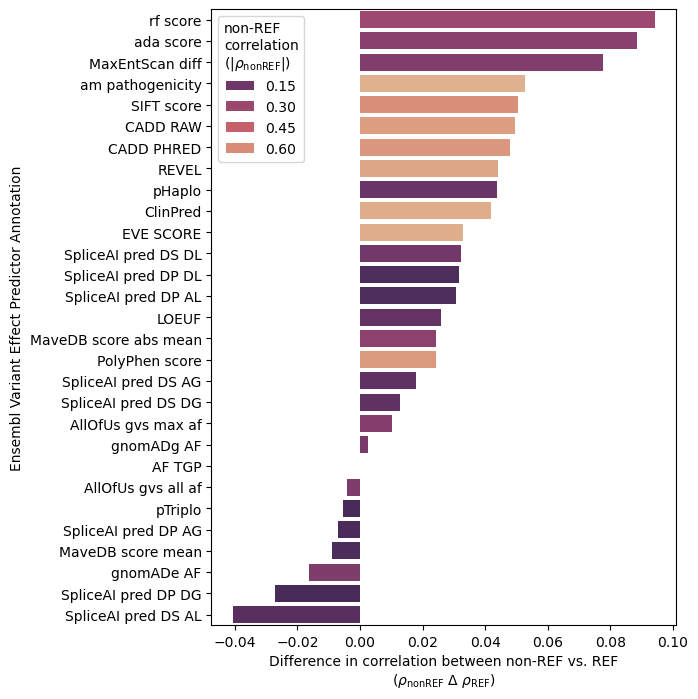

In [ ]:
r2_df.sort_values("r_diff", ascending=False, inplace=True)
r2_df.loc[:, "non_ref_r_abs"] = r2_df["non_ref_r"].abs()

plt.figure(figsize=(6, 8))  # Increased height to 12
sns.barplot(r2_df, x="r_diff", y="annotation", hue="non_ref_r_abs", palette="flare_r")
plt.legend(title="non-REF\ncorrelation\n"
           r"$(|ρ_{\text{nonREF}}|)$")
plt.ylabel("Ensembl Variant Effect Predictor Annotation")
plt.xlabel("Difference in correlation between non-REF vs. REF\n"
           r"($\rho_{\text{nonREF}} \text{ }  \Delta \text{ } \rho_{\text{REF}}$)")

# Replace underscores with spaces in y-tick labels
_ = plt.gca().set_yticklabels([label.get_text().replace('_', ' ') for label in plt.gca().get_yticklabels()])